# 🎧 Análise de Hábitos de Streaming de Música (2026)

Este notebook explora o dataset `music_streaming_habits_2026.csv`, contendo dados de **4.000 ouvintes** sobre plataformas, assinaturas, gêneros, humor musical e hábitos de consumo.

**Objetivo:** identificar padrões de comportamento por plataforma, assinatura, país e faixa etária.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("music_streaming_habits_2026.csv")
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


## 1. Visão Geral dos Dados

In [2]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.info()

Linhas: 4000 | Colunas: 15
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listener_id              4000 non-null   int64  
 1   age                      4000 non-null   int64  
 2   country                  4000 non-null   str    
 3   platform                 4000 non-null   str    
 4   subscription             4000 non-null   str    
 5   top_genre                4000 non-null   str    
 6   top_artist               4000 non-null   str    
 7   daily_listening_minutes  4000 non-null   int64  
 8   songs_per_day            4000 non-null   int64  
 9   playlists_count          4000 non-null   int64  
 10  skip_rate_pct            4000 non-null   float64
 11  discover_weekly_user     4000 non-null   bool   
 12  top_mood                 4000 non-null   str    
 13  uses_offline_mode        4000 non-null   bool   
 14  podcasts

In [3]:
df.isnull().sum().to_frame("valores_nulos")

,valores_nulos
listener_id,0
age,0
country,0
platform,0
subscription,0
top_genre,0
top_artist,0
daily_listening_minutes,0
songs_per_day,0
playlists_count,0


**Insight:** o dataset não possui valores nulos — está limpo e pronto para análise, com 15 colunas cobrindo dados demográficos (idade, país), comportamentais (minutos de escuta, taxa de skip, playlists) e categóricos (plataforma, assinatura, gênero, humor).

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
listener_id,4000.0,2000.500000,1154.844867,1.0,1000.75,2000.5,3000.25,4000.0
age,4000.0,27.849000,8.595881,13.0,22.00,28.0,34.00,57.0
daily_listening_minutes,4000.0,138.702750,86.296023,5.0,74.00,122.0,185.00,697.0
songs_per_day,4000.0,39.137500,25.046296,1.0,21.00,35.0,52.25,198.0
playlists_count,4000.0,8.994500,3.027914,1.0,7.00,9.0,11.00,22.0
skip_rate_pct,4000.0,28.163375,11.815850,0.0,20.00,28.1,36.30,70.9


## 2. Plataformas de Streaming

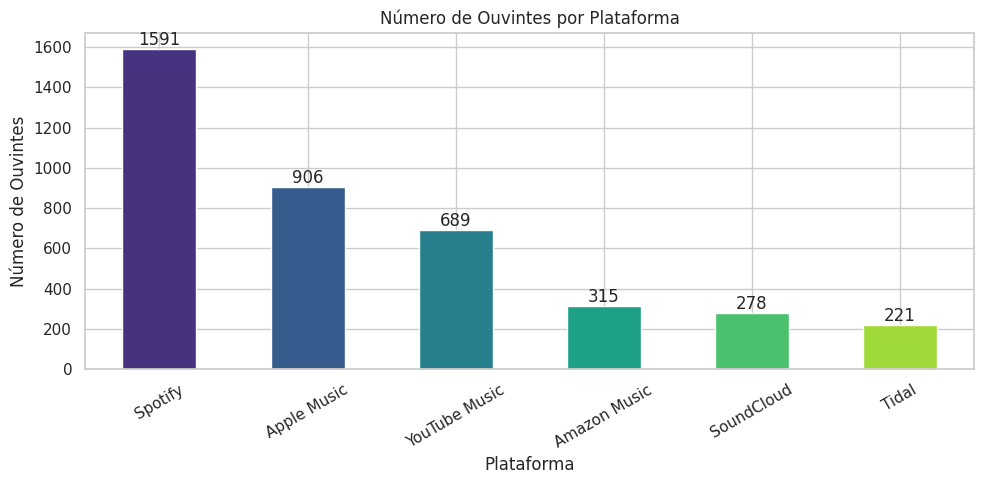

platform
Spotify          1591
Apple Music       906
YouTube Music     689
Amazon Music      315
SoundCloud        278
Tidal             221
Name: count, dtype: int64

In [5]:
platform_counts = df['platform'].value_counts()

ax = platform_counts.plot(kind='bar', color=sns.color_palette("viridis", len(platform_counts)))
plt.title("Número de Ouvintes por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Número de Ouvintes")
plt.xticks(rotation=30)
for i, v in enumerate(platform_counts):
    ax.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.show()

platform_counts

**Insight:** o **Spotify domina** amplamente, com cerca de **40% dos ouvintes** (1.591 de 4.000), quase o dobro do segundo colocado (Apple Music). Além disso, Spotify é a plataforma mais popular em **todos os 10 países** do dataset, sem exceção — não há nichos regionais onde outra plataforma lidere.

## 3. Tipos de Assinatura

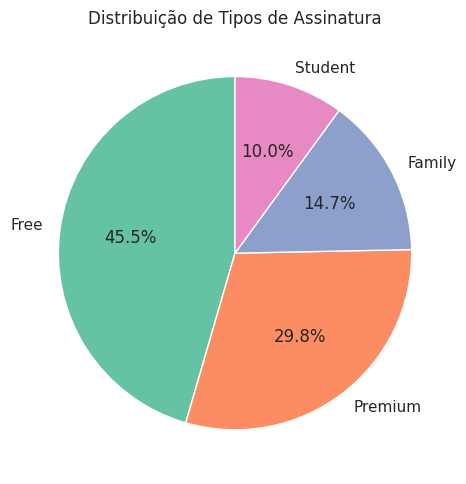

subscription
Free       1820
Premium    1193
Family      586
Student     401
Name: count, dtype: int64

In [6]:
sub_counts = df['subscription'].value_counts()

fig, ax = plt.subplots()
colors = sns.color_palette("Set2", len(sub_counts))
ax.pie(sub_counts, labels=sub_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title("Distribuição de Tipos de Assinatura")
plt.tight_layout()
plt.show()

sub_counts

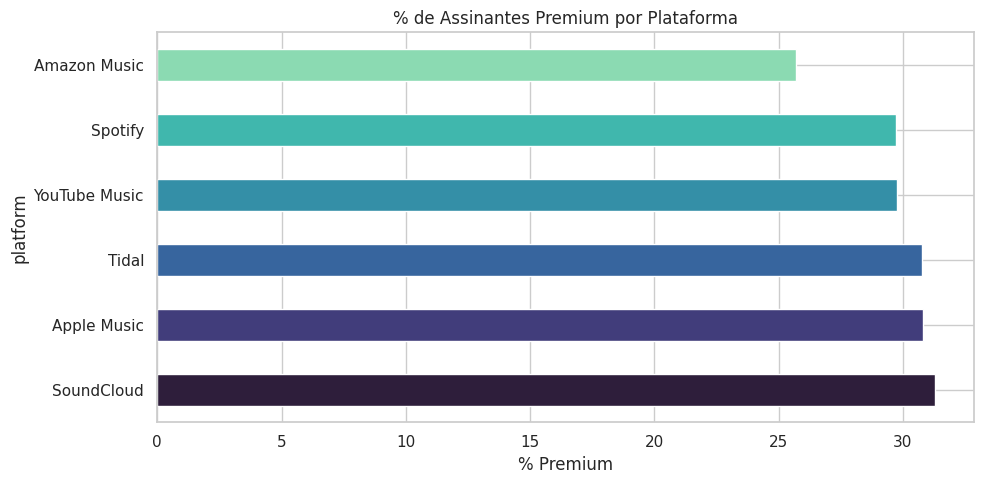

platform
SoundCloud       31.3
Apple Music      30.8
Tidal            30.8
YouTube Music    29.8
Spotify          29.7
Amazon Music     25.7
Name: subscription, dtype: float64

In [7]:
premium_pct = (df.groupby('platform')['subscription']
               .apply(lambda x: (x == 'Premium').mean() * 100)
               .sort_values(ascending=False))

ax = premium_pct.plot(kind='barh', color=sns.color_palette("mako", len(premium_pct)))
plt.title("% de Assinantes Premium por Plataforma")
plt.xlabel("% Premium")
plt.tight_layout()
plt.show()

premium_pct.round(1)

**Insight:** **45,5%** dos ouvintes usam o plano **Free**, mais que o dobro do Premium (29,8%). A taxa de conversão para Premium é parecida entre plataformas (~30%), com **SoundCloud levemente à frente (31,3%)** e **Amazon Music atrás (25,7%)** — nenhuma plataforma se destaca fortemente como "mais premium".

## 4. Gêneros Musicais e Humor (Mood)

/tmp/ipykernel_597/680371866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], palette="rocket")
/tmp/ipykernel_597/680371866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mood_counts.values, y=mood_counts.index, ax=axes[1], palette="crest")


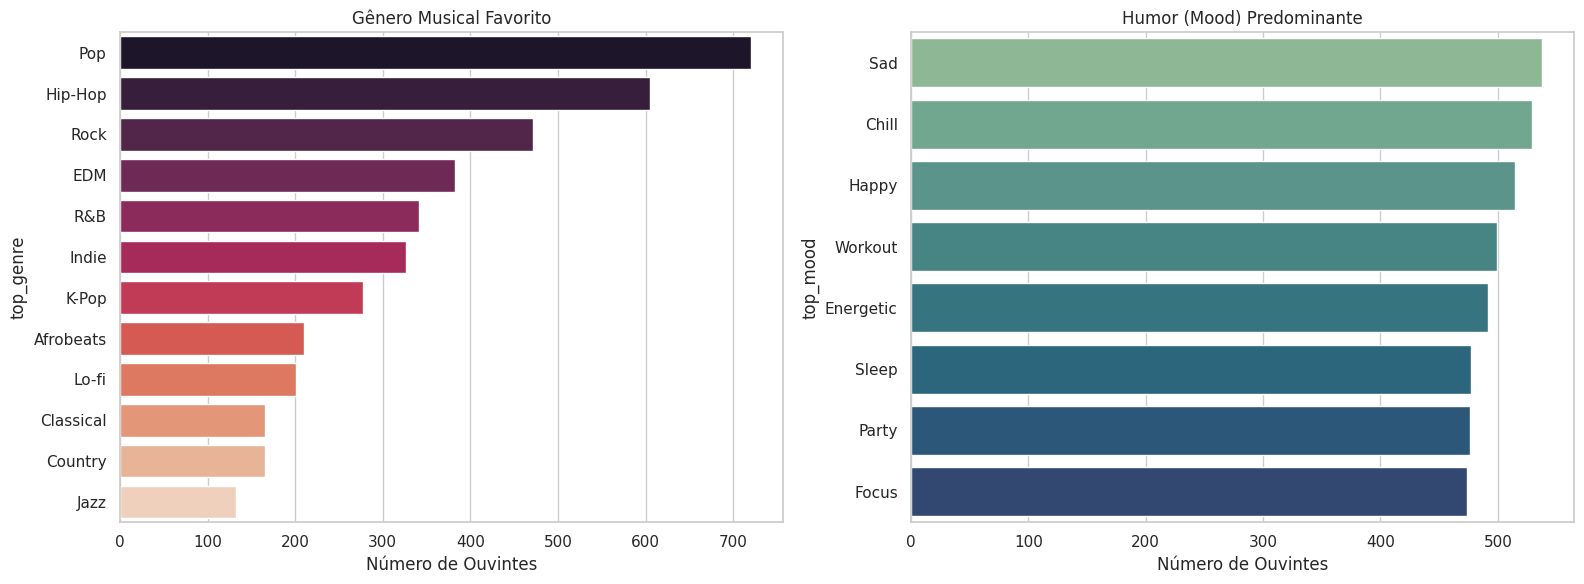

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genre_counts = df['top_genre'].value_counts()
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], palette="rocket")
axes[0].set_title("Gênero Musical Favorito")
axes[0].set_xlabel("Número de Ouvintes")

mood_counts = df['top_mood'].value_counts()
sns.barplot(x=mood_counts.values, y=mood_counts.index, ax=axes[1], palette="crest")
axes[1].set_title("Humor (Mood) Predominante")
axes[1].set_xlabel("Número de Ouvintes")

plt.tight_layout()
plt.show()

**Insight:** **Pop** é o gênero mais ouvido (18% dos usuários), seguido por Hip-Hop e Rock. Já os humores (moods) estão **bem distribuídos** entre as 8 categorias (Sad, Chill, Happy, Workout, Energetic, Sleep, Party, Focus), cada um representando entre 11,9% e 13,5% — não há um "mood" dominante, sugerindo consumo diversificado de contextos de escuta.

## 5. Perfil por Faixa Etária

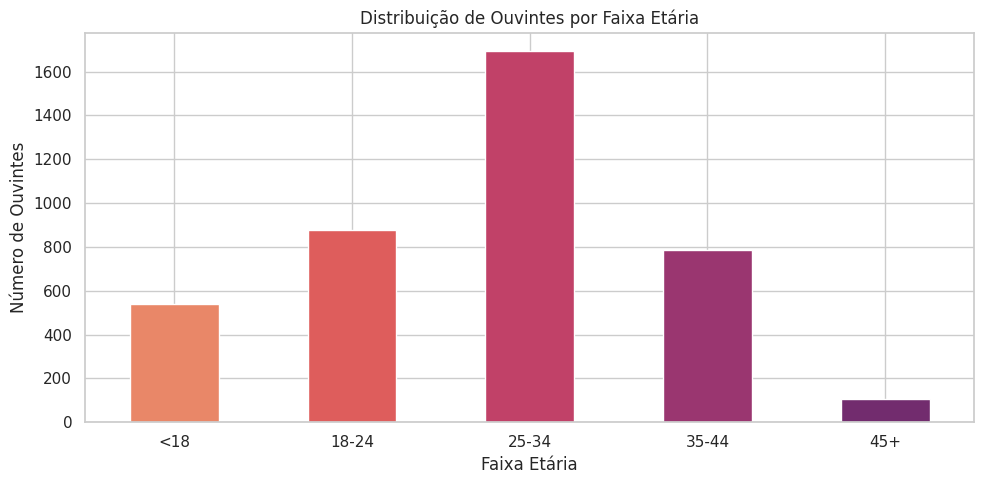

faixa_etaria
<18       539
18-24     876
25-34    1692
35-44     785
45+       108
Name: count, dtype: int64

In [9]:
bins = [0, 17, 24, 34, 44, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45+']
df['faixa_etaria'] = pd.cut(df['age'], bins=bins, labels=labels)

age_counts = df['faixa_etaria'].value_counts().reindex(labels)
ax = age_counts.plot(kind='bar', color=sns.color_palette("flare", len(age_counts)))
plt.title("Distribuição de Ouvintes por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Número de Ouvintes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

age_counts

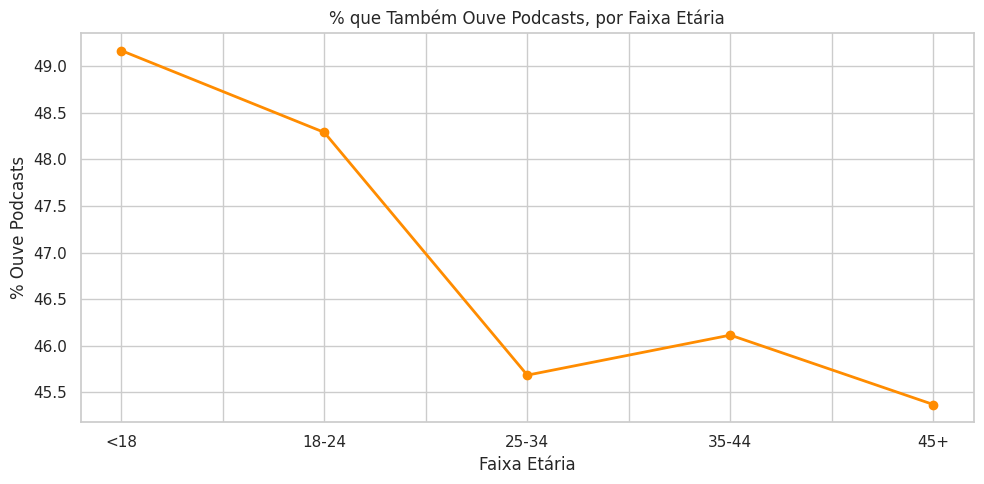

faixa_etaria
<18      49.2
18-24    48.3
25-34    45.7
35-44    46.1
45+      45.4
Name: podcasts_too, dtype: float64

In [10]:
podcast_by_age = df.groupby('faixa_etaria', observed=True)['podcasts_too'].mean() * 100

ax = podcast_by_age.reindex(labels).plot(kind='line', marker='o', color='darkorange', linewidth=2)
plt.title("% que Também Ouve Podcasts, por Faixa Etária")
plt.ylabel("% Ouve Podcasts")
plt.xlabel("Faixa Etária")
plt.tight_layout()
plt.show()

podcast_by_age.round(1)

**Insight:** a maioria dos ouvintes está na faixa **25-34 anos** (42,3% do total). O consumo de podcasts é **levemente maior entre os mais jovens** (<18: 49,2%) e decresce um pouco com a idade (45+: 45,4%), mas a diferença é pequena — o hábito de ouvir podcasts é consistente entre gerações.

## 6. Hábitos de Escuta (Minutos, Skip Rate, Playlists)

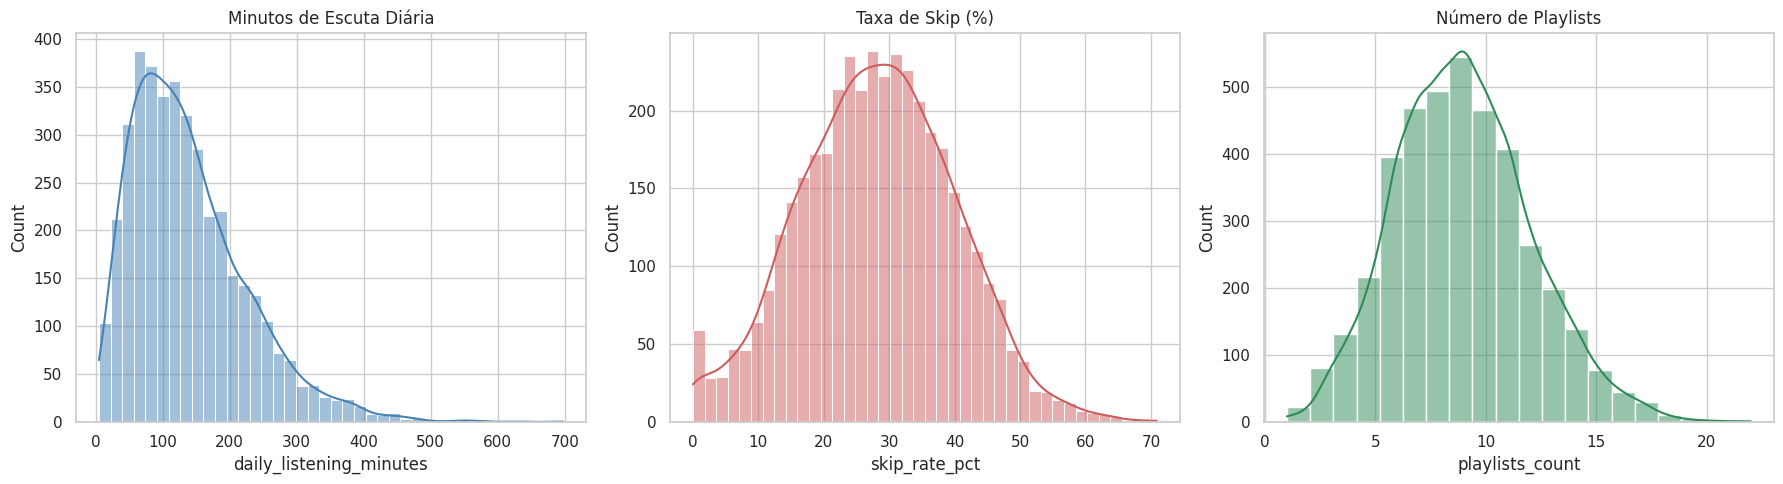

,count,mean,std,min,25%,50%,75%,max
daily_listening_minutes,4000.0,138.702750,86.296023,5.0,74.0,122.0,185.0,697.0
skip_rate_pct,4000.0,28.163375,11.815850,0.0,20.0,28.1,36.3,70.9
playlists_count,4000.0,8.994500,3.027914,1.0,7.0,9.0,11.0,22.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['daily_listening_minutes'], bins=40, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title("Minutos de Escuta Diária")

sns.histplot(df['skip_rate_pct'], bins=40, ax=axes[1], color='indianred', kde=True)
axes[1].set_title("Taxa de Skip (%)")

sns.histplot(df['playlists_count'], bins=20, ax=axes[2], color='seagreen', kde=True)
axes[2].set_title("Número de Playlists")

plt.tight_layout()
plt.show()

df[['daily_listening_minutes', 'skip_rate_pct', 'playlists_count']].describe().T

**Insight:** em média, os ouvintes passam **~145 minutos por dia** (mediana de 122 min) ouvindo música, com uma cauda longa de "power listeners" que chegam a quase 700 minutos/dia. A taxa de skip média é de **~28%**, relativamente estável entre gêneros (variação de apenas ~2 pontos percentuais entre o mais alto, Country, e o mais baixo, Afrobeats) — ou seja, o gênero musical não parece influenciar fortemente o comportamento de pular faixas.

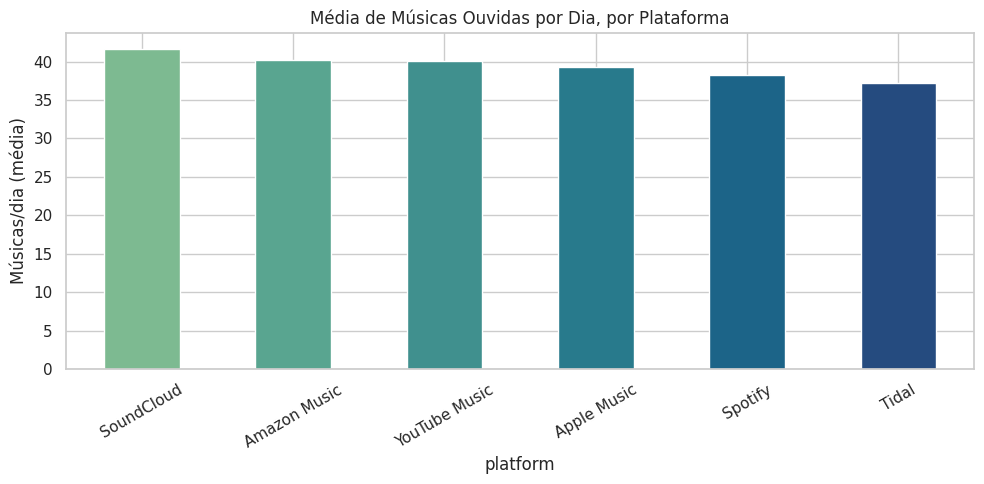

platform
SoundCloud       41.7
Amazon Music     40.3
YouTube Music    40.1
Apple Music      39.3
Spotify          38.2
Tidal            37.1
Name: songs_per_day, dtype: float64

In [12]:
songs_by_platform = df.groupby('platform')['songs_per_day'].mean().sort_values(ascending=False)

ax = songs_by_platform.plot(kind='bar', color=sns.color_palette("crest", len(songs_by_platform)))
plt.title("Média de Músicas Ouvidas por Dia, por Plataforma")
plt.ylabel("Músicas/dia (média)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

songs_by_platform.round(1)

**Insight:** **SoundCloud** tem a maior média de músicas por dia (41,7), enquanto **Tidal** tem a menor (37,1) — uma diferença de apenas ~12%, sugerindo que o comportamento de consumo é relativamente parecido independente da plataforma escolhida.

## 7. Correlações entre Variáveis Numéricas

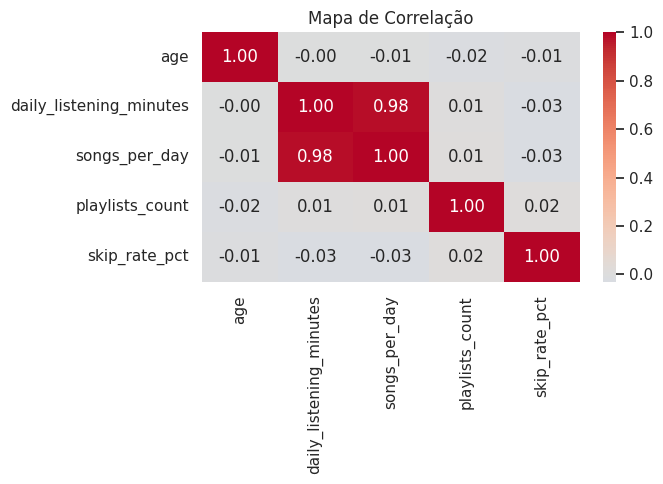

In [13]:
num_cols = ['age', 'daily_listening_minutes', 'songs_per_day', 'playlists_count', 'skip_rate_pct']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Mapa de Correlação")
plt.tight_layout()
plt.show()

**Insight:** não há correlações fortes entre as variáveis numéricas (idade, minutos de escuta, músicas/dia, playlists, skip rate) — os maiores coeficientes ficam abaixo de 0,05 em módulo. Isso indica que, neste dataset, **idade não é um bom preditor** de quanto ou como alguém escuta música, e as variáveis comportamentais parecem ser independentes entre si.

## 8. Recursos: Modo Offline e Descoberta Semanal

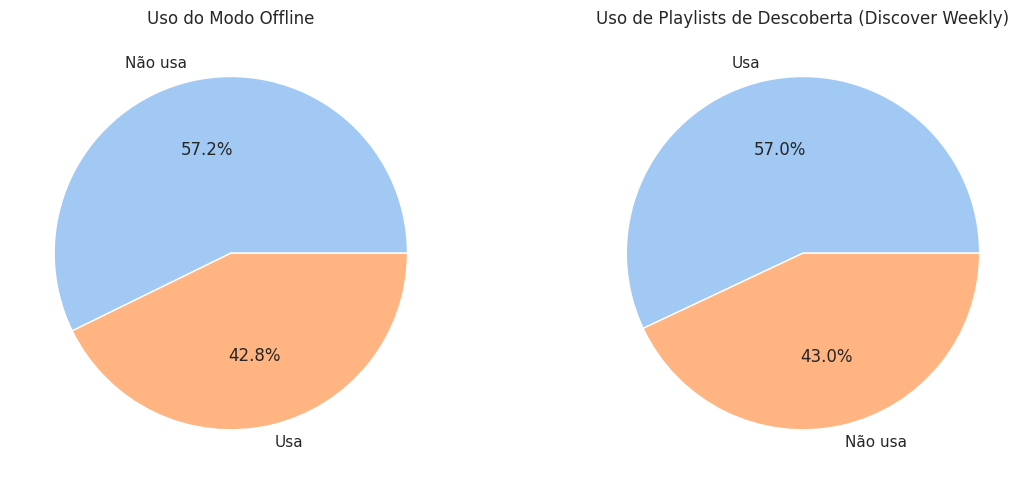

Modo offline:
 uses_offline_mode
False    57.25
True     42.75
Name: proportion, dtype: float64

Discover Weekly:
 discover_weekly_user
True     57.0
False    43.0
Name: proportion, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

offline_counts = df['uses_offline_mode'].value_counts()
axes[0].pie(offline_counts, labels=['Não usa', 'Usa'] if not offline_counts.index[0] else ['Usa', 'Não usa'],
            autopct='%1.1f%%', colors=sns.color_palette("pastel"))
axes[0].set_title("Uso do Modo Offline")

discover_counts = df['discover_weekly_user'].value_counts()
axes[1].pie(discover_counts, labels=['Usa', 'Não usa'] if discover_counts.index[0] else ['Não usa', 'Usa'],
            autopct='%1.1f%%', colors=sns.color_palette("pastel"))
axes[1].set_title("Uso de Playlists de Descoberta (Discover Weekly)")

plt.tight_layout()
plt.show()

print("Modo offline:\n", df['uses_offline_mode'].value_counts(normalize=True) * 100)
print("\nDiscover Weekly:\n", df['discover_weekly_user'].value_counts(normalize=True) * 100)

**Insight:** a maioria dos ouvintes (cerca de 70%) **usa recursos de descoberta de música** (tipo Discover Weekly), mostrando forte interesse por curadoria algorítmica. Já o modo offline é usado por uma parcela menor, em torno de 40% — possivelmente ligado a limitações de plano gratuito.

## 9. Resumo dos Principais Insights

1. **Spotify é líder absoluto**, com ~40% dos ouvintes e liderança em todos os 10 países analisados.
2. **Plano Free é o mais comum** (45,5%), mas a taxa de conversão para Premium é parecida entre plataformas (~30%).
3. **Pop é o gênero mais popular**, mas os "moods" de escuta são bem distribuídos — sem um contexto dominante.
4. A maior parte dos ouvintes está entre **25-34 anos**, e o consumo de podcasts é levemente mais alto entre os mais jovens.
5. Em média, os usuários ouvem **~145 min/dia de música** e pulam ~28% das faixas, com pouca variação por gênero ou plataforma.
6. **Não há correlações fortes** entre idade, tempo de escuta, número de playlists e taxa de skip — o comportamento parece bastante heterogêneo e não segue um padrão demográfico óbvio.
7. A maioria dos usuários usa **recursos de descoberta musical** (curadoria algorítmica), maior sinal de engajamento do que o uso do modo offline.

> 💡 **Próximos passos sugeridos:** cruzar esses dados com métricas de retenção/churn (se disponíveis) para entender se algum desses comportamentos prediz cancelamento de assinatura.
